# **Network Dynamics and Learning - Homework 1**

### Install Modules

In [ ]:
!pip install numpy
!pip install scipy
!pip install matplotlib
!pip install networkx
!pip install ecos osqp
!pip install --upgrade cvxpy ecos scs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.9 MB/s eta 0:00:00
  Attempting uninstall: cvxpy
    Found existing installation: cvxpy 1.6.7
    Uninstalling cvxpy-1.6.7:
      Successfully uninstalled cvxpy-1.6.7


### Import Modules

In [ ]:
import networkx as nx
import numpy as np
%matplotlib inline
import cvxpy as cp
import scipy.io
import scipy
from scipy.sparse import issparse, csc_matrix
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations
from itertools import chain

# **EXERCISE 1**

## E1 Part A

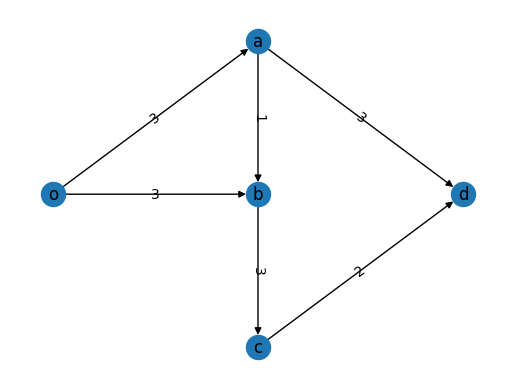

In [ ]:


#define G as a directed graph and add capacity and name to edge
G = nx.DiGraph()
G.add_nodes_from(['o','a','b','c','d'])
G.add_edges_from([('o','a',{'capacity':3, 'name': 'e1'}),
                    ('a','d',{'capacity':3, 'name': 'e2'}),
                    ('o','b',{'capacity':3, 'name': 'e3'}),
                    ('b','c',{'capacity':3, 'name': 'e4'}),
                    ('c','d',{'capacity':2, 'name': 'e5'}),
                    ('a','b',{'capacity':1, 'name': 'e6'})
                    ])
#visual configuration
positions={'o':[0,1], 'a':[1,2], 'b':[1,1] , 'c':[1,0],'d':[2,1]}
labels = nx.get_edge_attributes(G, 'capacity')

nx.draw_networkx_edge_labels(G, pos=positions,edge_labels=labels)
nx.draw(G,positions, with_labels=True)

In [ ]:

# Function to calculate all possible cuts
def nodepartition(G, source, sink):
    nodes = list(G.nodes())
    def all_combinations(nodes):
        return chain.from_iterable(combinations(nodes, r) for r in range(len(nodes)+1))
    partitions = []
    for combo in all_combinations(nodes):
        # Separate nodes into two disjoint sets
        set1 = set(combo)
        set2 = set(nodes) - set1
        # Ensure source and sink are in different sets for a valid cut

        if source in set1 and sink in set2:
            partitions.append((set1, set2))
    return partitions

# Function to calculate cut capacities
def calculation_cut_capacity(G, partitions):
    cut_capacities = []
    for (set1, set2) in partitions:
        capacity = sum(G[u][v]['capacity'] for u in set1 for v in set2 if G.has_edge(u, v))
        cut_capacities.append(capacity)
    return cut_capacities

# Calculate all possible cuts and their capacities
all_possible_partitions = nodepartition(G, 'o', 'd')
cutcapacity_of_each_partition = calculation_cut_capacity(G, all_possible_partitions)

# Print all possible cuts with their capacities
print("These are all the possible cuts, i.e., all possible node partitions:\n")
for i, partition in enumerate(all_possible_partitions):
    print(f"Cut partition: {partition} -> Cut capacity: {cutcapacity_of_each_partition[i]}")

# Find the minimum cut
min_cut_capacity, min_cut = nx.minimum_cut(G, 'o', 'd')
print("\nMinimum cut capacity:", min_cut_capacity) # 5
print("Minimum cut partitions:", min_cut) # ({'a', 'o', 'b', 'c'}, {'d'})

# Calculate the maximum flow
max_flow_value = nx.maximum_flow_value(G, 'o', 'd')
print("\nMaximum flow value:", max_flow_value)


cut_value, (set1, set2) = nx.minimum_cut(G, 'o', 'd')
cutset = set()
for u in set1:
  for v in G[u]:
    if v in set2:
      cutset.add((u,v,G[u][v]['capacity']))

print("\nEdges in the minimum cut with capacities:")
for u, v, capacity in cutset:
    print(f"Edge {u} -> {v} with capacity {capacity}")

These are all the possible cuts, i.e., all possible node partitions:

Cut partition: ({'o'}, {'b', 'a', 'd', 'c'}) -> Cut capacity: 6
Cut partition: ({'a', 'o'}, {'b', 'd', 'c'}) -> Cut capacity: 7
Cut partition: ({'b', 'o'}, {'a', 'd', 'c'}) -> Cut capacity: 6
Cut partition: ({'o', 'c'}, {'b', 'a', 'd'}) -> Cut capacity: 8
Cut partition: ({'b', 'a', 'o'}, {'d', 'c'}) -> Cut capacity: 6
Cut partition: ({'a', 'o', 'c'}, {'b', 'd'}) -> Cut capacity: 9
Cut partition: ({'b', 'o', 'c'}, {'a', 'd'}) -> Cut capacity: 5
Cut partition: ({'b', 'a', 'o', 'c'}, {'d'}) -> Cut capacity: 5

Minimum cut capacity: 5
Minimum cut partitions: ({'b', 'a', 'o', 'c'}, {'d'})

Maximum flow value: 5

Edges in the minimum cut with capacities:
Edge a -> d with capacity 3
Edge c -> d with capacity 2


## E1 Part B

Extra capacity 0: maximum flow = 5
Step 0: Partitions:{'b', 'a', 'o', 'c'}, {'d'} - Linking Edges:[('a', 'd'), ('c', 'd')]
a->d: capacity incremented
Extra capacity 1: maximum flow = 5
Step 1: Partitions:{'b', 'o', 'c'}, {'a', 'd'} - Linking Edges:[('o', 'a'), ('c', 'd')]
o->a: capacity incremented
Extra capacity 2: maximum flow = 6
Step 2: Partitions:{'b', 'a', 'o', 'c'}, {'d'} - Linking Edges:[('a', 'd'), ('c', 'd')]
a->d: capacity incremented
Extra capacity 3: maximum flow = 6
Step 3: Partitions:{'b', 'o', 'c'}, {'a', 'd'} - Linking Edges:[('o', 'a'), ('c', 'd')]
o->a: capacity incremented
Extra capacity 4: maximum flow = 7
Step 4: Partitions:{'b', 'a', 'o', 'c'}, {'d'} - Linking Edges:[('a', 'd'), ('c', 'd')]
a->d: capacity incremented
Extra capacity 5: maximum flow = 7
Step 5: Partitions:{'b', 'o', 'c'}, {'a', 'd'} - Linking Edges:[('o', 'a'), ('c', 'd')]
o->a: capacity incremented
Extra capacity 6: maximum flow = 8
Step 6: Partitions:{'b', 'a', 'o', 'c'}, {'d'} - Linking Edges:[(

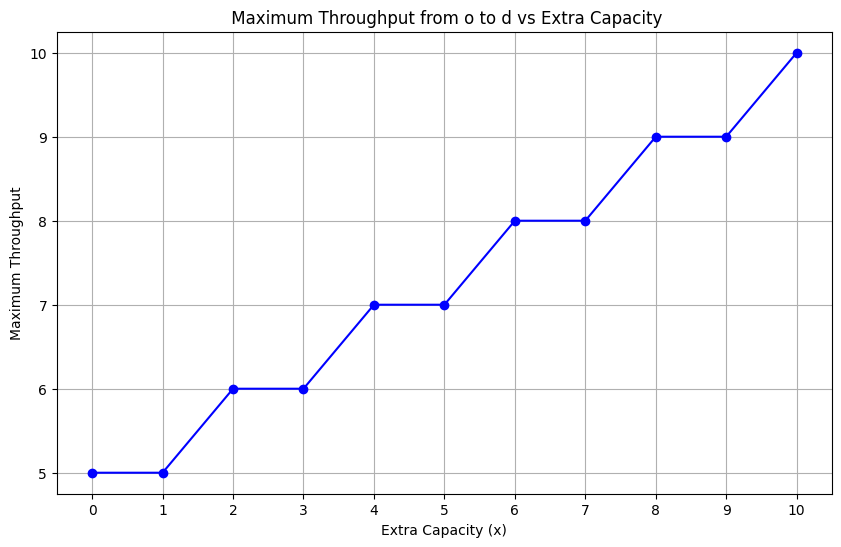

In [ ]:
def optimized_iterative_capacity_check(G,extra_capacity):


  G_new = G.copy()

  throughput = []

  # Find linking edges (edges between the partitions) in
  for i in range(extra_capacity + 1):  # include x=0
        # Compute max flow
        flow_value, flow_dict = nx.maximum_flow(G_new, 'o', 'd')
        throughput.append(flow_value)
        print(f"Extra capacity {i}: maximum flow = {flow_value}")

        # Find min cut and increase one edge’s capacity
        if i < extra_capacity:
            min_cut_value, (partition1, partition2) = nx.minimum_cut(G_new, 'o', 'd')
            linking_edges = [(u, v) for u, v in G_new.edges() if (u in partition1 and v in partition2)]
            print(f'Step {i}: Partitions:{partition1}, {partition2} - Linking Edges:{linking_edges}')
            G_new[linking_edges[0][0]][linking_edges[0][1]]['capacity'] += 1
            print(f'{linking_edges[0][0]}->{linking_edges[0][1]}: capacity incremented')

  return throughput



 # Calculate the Maximum Flow
  flow_value, flow_dict = nx.algorithms.flow.maximum_flow(G_new,'o','d')
  throughput.append(flow_value)
  print(f"extera capacity{extra_capacity} : maximum flow = {flow_value}")



  print(f'Maximum flow_value: {max_flow_value[0]}')
  G_new_labels = nx.get_edge_attributes(G_new, 'capacity')
  nx.draw_networkx_edge_labels(G_new, positions, edge_labels=G_new_labels)
  nx.draw(G_new, positions, with_labels=True)

# Calculate maximum flow for each value of x from 0 to 10
extra_capacity = 10
throughput = optimized_iterative_capacity_check(G, extra_capacity)

# Plotting the maximum throughput as a function of x
x_values = np.arange(0, extra_capacity+1)
plt.figure(figsize=(10, 6))
plt.plot(x_values, throughput, marker='o', color='blue')
plt.title(' Maximum Throughput from o to d vs Extra Capacity')
plt.xlabel('Extra Capacity (x)')
plt.ylabel('Maximum Throughput')
plt.grid()
plt.xticks(x_values)
plt.show()


## E1 Part C

Extra capacity 0: maximum flow = 6
Step 0: Partitions:{'b', 'a', 'o', 'c'}, {'d'} - Linking Edges:[('o', 'd'), ('a', 'd'), ('c', 'd')]
o->d: capacity incremented
Extra capacity 1: maximum flow = 7
Step 1: Partitions:{'b', 'a', 'o', 'c'}, {'d'} - Linking Edges:[('o', 'd'), ('a', 'd'), ('c', 'd')]
o->d: capacity incremented
Extra capacity 2: maximum flow = 8
Step 2: Partitions:{'b', 'a', 'o', 'c'}, {'d'} - Linking Edges:[('o', 'd'), ('a', 'd'), ('c', 'd')]
o->d: capacity incremented
Extra capacity 3: maximum flow = 9
Step 3: Partitions:{'b', 'a', 'o', 'c'}, {'d'} - Linking Edges:[('o', 'd'), ('a', 'd'), ('c', 'd')]
o->d: capacity incremented
Extra capacity 4: maximum flow = 10
Step 4: Partitions:{'b', 'a', 'o', 'c'}, {'d'} - Linking Edges:[('o', 'd'), ('a', 'd'), ('c', 'd')]
o->d: capacity incremented
Extra capacity 5: maximum flow = 11
Step 5: Partitions:{'b', 'a', 'o', 'c'}, {'d'} - Linking Edges:[('o', 'd'), ('a', 'd'), ('c', 'd')]
o->d: capacity incremented
Extra capacity 6: maximum 

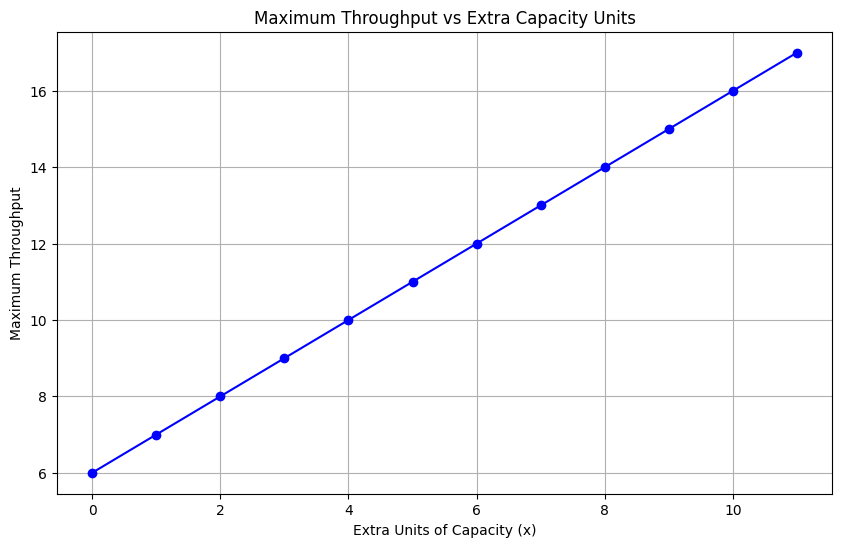

In [ ]:
G_new = G.copy()
# add edge e8 between o and d with capacity 1
G_new.add_edge('o', 'd' , capacity=1)
# Apply the optimized method on the graph
extra_capacity = 11
throughput = optimized_iterative_capacity_check(G_new.copy(), extra_capacity)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(range(extra_capacity + 1), throughput, marker='o', color='b')
plt.xlabel('Extra Units of Capacity (x)')
plt.ylabel('Maximum Throughput')
plt.title('Maximum Throughput vs Extra Capacity Units')
plt.grid(True)
plt.show()



# **Exercise 2**

Consider the simple graph **G = (V, E)** in *Figure 2*.

---

**(a)** Compute the **Katz centrality**, with β = 0.15 and **uniform intrinsic centrality μ**.  


**(b)** Write a **distributed algorithm** for the computation of **Page-rank centrality**,  
with β = 0.15 and **uniform intrinsic centrality μ**.  

**(c)** Explain the results of points (a) and (b), focusing on the **centralities of nodes n₆ and n₉**.  

**(d)** Compute the **Page-Rank centrality** with **uniform intrinsic centrality μ** and for every  

$$
\beta \in \{ 0,\; \tfrac{1}{4},\; \tfrac{1}{2},\; \tfrac{3}{4},\; 1 \}.
$$

Is the difference between the centrality of node *n₆* and node *n₉* monotone in β?  
Explain the results, focusing in particular on the extreme values of β.


In [ ]:
from __future__ import annotations
import numpy as np
from typing import Dict, List, Iterable, Tuple

import matplotlib.pyplot as plt
import networkx as nx
%matplotlib inline
plt.rcParams["figure.figsize"] = (4, 3)

/tmp/ipython-input-3493077165.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


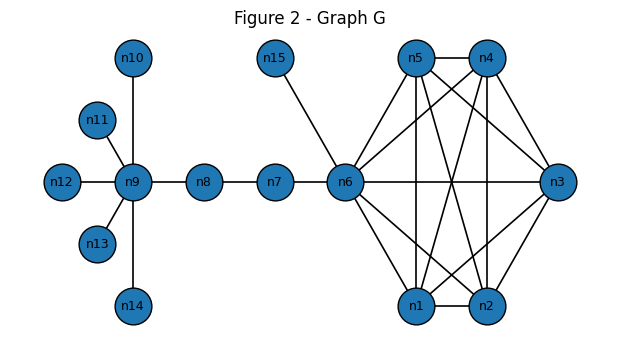

In [ ]:
#construction and shape the graph

def build_figure2_graph(directed: bool = True):
    UG = nx.Graph()

    # group n1...n5
    group = ["n1","n2","n3","n4","n5"]
    UG.add_nodes_from([f"n{i}" for i in range(1,16)])
    for i in range(len(group)):
        for j in range(i+1, len(group)):
            UG.add_edge(group[i], group[j])

    # n6 to group + n7 + n15
    for v in group + ["n7","n15"]:
        UG.add_edge("n6", v)

    # path n7-n8-n9
    UG.add_edge("n7","n8")
    UG.add_edge("n8","n9")

    # star at n9: n10..n14
    for k in range(10,15):
        UG.add_edge("n9", f"n{k}")

    return UG.to_directed() if directed else UG


POS = {"n12":[1,2],"n9":[2,2], "n8":[3,2], "n7":[4,2], "n6":[5,2], "n3":[8,2],
       "n13":[1.5,1], "n11":[1.5,3],"n14":[2,0],"n1":[6,0],"n2":[7,0],
       "n10":[2,4],"n15":[4,4],"n5":[6,4],"n4":[7,4]}



def draw_figure2(G):
    plt.figure(figsize=(6,3))
    nx.draw(G.to_undirected(), POS, with_labels=True,
            edgecolors="black", node_size=700, width=1.2, font_size=9)
    plt.title("Figure 2 - Graph G")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


G = build_figure2_graph(directed=True)
draw_figure2(G)

---
### **Adjacency Matrix and Column–Stochastic Matrix**

#### **Adjacency Matrix  \(A\)**

- Represents the structure of the directed graph.  
- Each element:

$$
A_{ij} =
\begin{cases}
1, & \text{if there is an edge } j \to i \\
0, & \text{otherwise}
\end{cases}
$$

- Each **column** corresponds to one node’s outgoing edges → the **sum of column *j*** equals the **out-degree** of node *j*.

 Used in Katz Centrality:

$$
x = (I - \beta A)^{-1}\mu
$$

---

#### **Column–Stochastic Matrix  \(P\)**

- Obtained by normalizing each column of \(A\) so that every column sums to 1:

$$
P_{ij} = \frac{A_{ij}}{\text{outdeg}(j)}
$$

- \(P\) represents the **transition probabilities** of a random walk:  
  if you are at node *j*, the probability of moving to neighbor *i* is $(1/\text{outdeg}(j)$).

 Used in PageRank:

$$
x = \beta P x + (1-\beta)\mu
$$

---


In [ ]:

def adjacency_matrix(G: nx.DiGraph, nodelist: List[str]) -> np.ndarray:
    idx = {node: k for k, node in enumerate(nodelist)}
    A = np.zeros((len(nodelist), len(nodelist)), dtype=float)
    for u, v in G.edges():
        A[idx[v], idx[u]] = 1
    return A


def column_stochastic_from_adjacency(A: np.ndarray) -> np.ndarray:
    outdeg = A.sum(axis=0)  # sum arrays of each column # outdegree of each node
    P = np.zeros_like(A, dtype=float)
    nonzero = outdeg > 0
    P[:, nonzero] = A[:, nonzero] / outdeg[nonzero]
    return P

# **E2 part a**
# **Katz Centrality**



- **Goal:** Compute Katz centrality with β = 0.15 and uniform intrinsic centrality μ.  
- **Idea:** Measures node influence by counting **all possible paths**, giving shorter paths higher weight.  
- **Formula:**
  $$
  x = \beta A x + \mu
  \quad \Longrightarrow \quad
  x = (I - \beta A)^{-1}\mu
  $$


- Here:
  - $A$: adjacency matrix  
  - $\beta$: attenuation factor (must be $< 1 / \text{spectral radius of } A$)  
  - $\mu$: intrinsic centrality (usually uniform)

- **Interpretation:**  
  Nodes connected to other influential nodes gain higher scores.  
  Computed by solving the linear system $((I - \beta A)x = \mu$
  
  ---




In [ ]:

def katz_centrality(G, beta, mu=None, nodelist=None):

    if nodelist is None:
        nodelist = list(G.nodes())
    A = adjacency_matrix(G, nodelist)
    N = A.shape[0]

    if mu is None:
        mu = np.ones(N)

    I = np.eye(N)
    M = I - beta * A
    M_inv = np.linalg.inv(M)
    x = M_inv @ mu

    return {nodelist[i]: float(x[i]) for i in range(N)}


#computation
if __name__ == "__main__":
    np.set_printoptions(precision=6, suppress=True)
    G = build_figure2_graph()
    nodelist = [f"n{i}" for i in range(1, 16)]  # fixed node order for reproducibility
    N = len(nodelist)


    #  Katz centrality at β = 0.15 with uniform μ
    print(" (a) Katz centrality (β = 0.15, uniform μ)")
    beta_katz = 0.15
    katz_mu = np.ones(N)  # uniform intrinsic centrality (scale arbitrary)
    katz = katz_centrality(G, beta=beta_katz, mu=katz_mu, nodelist=nodelist)

    # Sort and pretty print
    katz_sorted = sorted(katz.items(), key=lambda kv: kv[1], reverse=True)
    print("Top Katz scores:")
    for key, value in katz_sorted:
        print(f"  {key:>3s}: {value:.6f}")

    print(f"\nKatz[n6] = {katz['n6']:.6f} ")
    print(f" Katz[n9] = {katz['n9']:.6f} ")
    print(f"Difference (n6 - n9) = {katz['n6'] - katz['n9']:.6e}\n")

 (a) Katz centrality (β = 0.15, uniform μ)
Top Katz scores:
   n6: 4.766901
   n1: 4.287588
   n2: 4.287588
   n3: 4.287588
   n4: 4.287588
   n5: 4.287588
   n9: 2.247507
   n7: 1.959697
  n15: 1.715035
   n8: 1.631081
  n12: 1.337126
  n10: 1.337126
  n11: 1.337126
  n13: 1.337126
  n14: 1.337126

Katz[n6] = 4.766901 
 Katz[n9] = 2.247507 
Difference (n6 - n9) = 2.519394e+00




# **E2 part b**
# **Distributed PageRank Centrality**

- **Goal:** Implement a *distributed algorithm* for PageRank with β = 0.15 and uniform μ.  
- **Idea:** Each node updates its rank using only information from its neighbors (message passing).  
- **Formula:**
$$
  x_i(k+1) = \beta \sum_{j \in In(i)} \frac{x_j(k)}{\text{outdeg}(j)} + (1-\beta)\mu_i
$$
  or in matrix form:
  $$
  x = \beta P x + (1-\beta)\mu
  $$

  or equivalently,

$$
(I - \beta P)x = (1-\beta)\mu
$$

- Here:
  - $P_{ij} = \dfrac{A_{ij}}{\operatorname{outdeg}(j)}$: transition probability  
  - $\beta$: damping factor (typ. 0.85 or 0.15 in exercises)  
  - $\mu$: teleportation vector (
- **Interpretation:**

  
  - With probability β, a “random surfer” follows a link.  
  - With probability (1 − β), they teleport to a random node (μ).  
  - The process converges to a stable vector \(x\) — the PageRank centrality.

---


In [ ]:
def pagerank_power_iteration(G: nx.DiGraph,
                             beta: float,
                             mu: np.ndarray | None = None,
                             nodelist: List[str] | None = None,
                             tol: float = 1e-12,
                             max_iter: int = 10_000) -> Dict[str, float]:

    if nodelist is None:
        nodelist = list(G.nodes())
    A = adjacency_matrix(G, nodelist)
    P = column_stochastic_from_adjacency(A)

    N = A.shape[0]
    if mu is None:
        mu = np.ones(N) / N
    else:
        mu = mu / mu.sum()

    # Fix dangling nodes (columns with sum 0) by replacing with μ (standard PageRank handling)
    outdeg = A.sum(axis=0)
    dangling = (outdeg == 0)
    if dangling.any():
        P[:, dangling] = mu.reshape(-1, 1)   #For columns with outdag[g]=0, column p will be mu

    x = np.ones(N) / N
    for _ in range(max_iter):
        x_new = beta * (P @ x) + (1 - beta) * mu
        if np.linalg.norm(x_new - x, 1) < tol:
            x = x_new
            break
        x = x_new

    return {nodelist[i]: float(x[i]) for i in range(N)}


def pagerank_distributed(G: nx.DiGraph,
                         beta: float,
                         mu: np.ndarray | None = None,
                         nodelist: List[str] | None = None,
                         tol: float = 1e-12,
                         max_iter: int = 10_000) -> Dict[str, float]:


    if nodelist is None:
        nodelist = list(G.nodes())
    index = {v: i for i, v in enumerate(nodelist)}
    N = len(nodelist)

    # Uniform μ by default, normalized to sum 1
    if mu is None:
        mu = np.ones(N) / N
    else:
        mu = mu / mu.sum()

    # Precompute out-neighbors and in-neighbors
    out_neighbors = {v: list(G.successors(v)) for v in nodelist}
    in_neighbors  = {v: list(G.predecessors(v)) for v in nodelist}
    outdeg = np.array([len(out_neighbors[v]) for v in nodelist], dtype=float)

    # Initialize x uniformly
    x = np.ones(N) / N

    # Identify dangling nodes
    dangling_mask = (outdeg == 0)

    for _ in range(max_iter):
        # Prepare incoming sums (messages)
        incoming = np.zeros(N, dtype=float)

        # Non-dangling: push x_i/outdeg(i) to neighbors
        for i, v in enumerate(nodelist):
            if outdeg[i] > 0:
                share = x[i] / outdeg[i]
                for w in out_neighbors[v]:
                    incoming[index[w]] += share

        # Dangling: redistribute to all according to μ (standard PageRank fix)
        if dangling_mask.any():
            dangling_mass = x[dangling_mask].sum()
            if dangling_mass > 0:
                incoming += dangling_mass * mu

        # Local update at each node (uses only its received sum)
        x_new = beta * incoming + (1 - beta) * mu

        # Convergence check
        if np.linalg.norm(x_new - x, 1) < tol:
            x = x_new
            break
        x = x_new

    return {nodelist[i]: float(x[i]) for i in range(N)}

#computation
if __name__ == "__main__":
    np.set_printoptions(precision=6, suppress=True)
    G = build_figure2_graph()
    nodelist = [f"n{i}" for i in range(1, 16)]  # fixed node order for reproducibility
    N = len(nodelist)

    #  Distributed PageRank (β = 0.15, uniform μ)
    print(" (b) PageRank via distributed message passing (β = 0.15, uniform μ)")
    beta_pr = 0.15
    pr_mu = np.ones(N) / N  # PageRank preference vector (unit-sum)
    pr_distributed = pagerank_distributed(G, beta=beta_pr, mu=pr_mu, nodelist=nodelist)
    pr_reference   = pagerank_power_iteration(G, beta=beta_pr, mu=pr_mu, nodelist=nodelist)

    # Validate distributed vs centralized
    max_abs_err = max(abs(pr_distributed[v] - pr_reference[v]) for v in nodelist)
    print(f"Max |distributed - centralized| error: {max_abs_err:.3e}")

    # Sort and print PageRank
    pr_sorted = sorted(pr_distributed.items(), key=lambda kv: kv[1], reverse=True)
    print("PageRank scores (distributed):")
    for v, val in pr_sorted:
        print(f"  {v:>3s}: {val:.8f}")
    print(f"\nPR[n6] = {pr_distributed['n6']:.8f} ")
    print(f"PR[n9] = {pr_distributed['n9']:.8f} ")
    print(f"Difference (n6 - n9) = {pr_distributed['n6'] - pr_distributed['n9']:.6e}\n")

 (b) PageRank via distributed message passing (β = 0.15, uniform μ)
Max |distributed - centralized| error: 0.000e+00
PageRank scores (distributed):
   n9: 0.10595747
   n6: 0.08011496
   n1: 0.06634479
   n2: 0.06634479
   n3: 0.06634479
   n4: 0.06634479
   n5: 0.06634479
   n8: 0.06405467
   n7: 0.06318752
  n10: 0.05931560
  n11: 0.05931560
  n12: 0.05931560
  n13: 0.05931560
  n14: 0.05931560
  n15: 0.05838342

PR[n6] = 0.08011496 
PR[n9] = 0.10595747 
Difference (n6 - n9) = -2.584251e-02



---
# **E2 part c**
# **Interpretation of Results**

- **Goal:** Compare the centralities of nodes **n₆** and **n₉** obtained from Katz and PageRank.  
- **Observation:**
  - **n₆** connects the dense K₅ core to the outer chain → high influence via well-connected neighbors.  
  - **n₉** is the hub of a star (many leaves) but its neighbors are low-degree nodes → less global impact.
- Therefore, for small β (short paths more important):
 $$
  4.766901= \text{Katz}(n_6) > \text{Katz}(n_9) = 2.247507
  $$
  and similarly for PageRank with β = 0.15:
  $$
  0.08011496 = \text{PR}(n_6) <  \text{PR}(n_9) = 0.10595747
  $$
- The difference reflects how each node connects to *central* vs *peripheral* parts of the graph.

---

In [ ]:
print("(c) Comparison focus: nodes n6 vs n9")
print("Reported above for both Katz and PageRank at β = 0.15.\n")


 (c) Comparison focus: nodes n6 vs n9
Reported above for both Katz and PageRank at β = 0.15.



---

# **E2 Part d**
# **PageRank vs β — Monotonicity Analysis**

- We compute PageRank for:
  $$
  \beta \in \{0,\; \tfrac{1}{4},\; \tfrac{1}{2},\; \tfrac{3}{4},\; 1\}
  $$
  with uniform μ.

- **Formula used:**
  $$
  x(\beta) = \beta P x(\beta) + (1-\beta)\mu
  $$
  and we analyze the difference
  $$
  \Delta(\beta) = \text{PR}_{n_6}(\beta) - \text{PR}_{n_9}(\beta)
  $$

- **Interpretation:**
  - For β = 0 → \(x = $mu$): all nodes equal → Δ = 0  
  - For intermediate β: random-walk influence dominates → Δ(β) may decrease or increase  
  - For β = 1 (pure random walk on undirected graph):  
    $$
    x_i \propto \text{deg}(i)
    $$
    → both n₆ and n₉ have degree 7 → Δ ≈ 0

- Since Δ(β) changes sign, the sequence is **not monotone**:  
  $$
  \text{Δ(β) is not monotonic in β.}
  $$

---

In [ ]:
def pagerank_over_betas(G: nx.DiGraph,
                        betas: Iterable[float],
                        mu: np.ndarray | None = None,
                        nodelist: List[str] | None = None,
                        use_distributed: bool = False) -> Dict[float, Dict[str, float]]:

    if nodelist is None:
        nodelist = list(G.nodes())

    results = {}
    for beta in betas:
        if use_distributed:
            pr = pagerank_distributed(G, beta, mu=mu, nodelist=nodelist)
        else:
            pr = pagerank_power_iteration(G, beta, mu=mu, nodelist=nodelist)
        results[beta] = pr
    return results


def is_monotone(seq: List[float]) -> Tuple[bool, str]:  # Check whether a sequence is monotone nondecreasing or nonincreasing.

    nondec = all(seq[i] <= seq[i+1] + 1e-15 for i in range(len(seq) - 1))
    noninc = all(seq[i] >= seq[i+1] - 1e-15 for i in range(len(seq) - 1))
    if nondec and not noninc:
        return True, "nondecreasing"
    if noninc and not nondec:
        return True, "nonincreasing"
    if nondec and noninc:
        return True, "constant"
    return False, "not monotone"

#computation
if __name__ == "__main__":
    np.set_printoptions(precision=6, suppress=True)
    G = build_figure2_graph()
    nodelist = [f"n{i}" for i in range(1, 16)]  # fixed node order for reproducibility
    N = len(nodelist)

    #   PageRank sweep over β and monotonicity
    print(" (d) PageRank for β ∈ {0, 1/4, 1/2, 3/4, 1} (uniform μ)")
    betas = [0.0, 0.25, 0.5, 0.75, 1.0]
    pr_by_beta = pagerank_over_betas(G, betas, mu=pr_mu, nodelist=nodelist, use_distributed=False)

    # Table: beta, PR(n6), PR(n9), diff
    print("_" * 64)
    print(f"{'β':>6}  {'PR(n6)':>14}  {'PR(n9)':>14}  {'n6 - n9':>14}  {'sum(x)':>10}")
    print("_" * 70)
    print("_" * 70)

    diffs = []
    for b in betas:
        d = pr_by_beta[b]
        s = sum(d.values())
        diff = d['n6'] - d['n9']
        diffs.append(diff)
        print(f"{b:6.2f}  {d['n6']:14.8f}  {d['n9']:14.8f}  {diff:14.8e}  {s:10.6f}")
    print("_" * 70)


    # Monotonicity check of the difference sequence
    monotone_flag, monotone_kind = is_monotone(diffs)
    print("\nDifferences sequence Δ(β) = PR(n6) - PR(n9):")
    for b, dv in zip(betas, diffs):
        print(f"  β={b:>4}: Δ = {dv:.8e}")
    verdict = f"Yes, {monotone_kind}" if monotone_flag else "No, not monotone"
    print(f"\nIs Δ(β) monotone in β?  {verdict}")




 (d) PageRank for β ∈ {0, 1/4, 1/2, 3/4, 1} (uniform μ)
________________________________________________________________
     β          PR(n6)          PR(n9)         n6 - n9      sum(x)
______________________________________________________________________
______________________________________________________________________
  0.00      0.06666667      0.06666667  0.00000000e+00    1.000000
  0.25      0.08750664      0.12697773  -3.94710887e-02    1.000000
  0.50      0.10140399      0.16669255  -6.52885611e-02    1.000000
  0.75      0.11060449      0.19111594  -8.05114506e-02    1.000000
  1.00      0.14583333      0.12500000  2.08333333e-02    1.000000
______________________________________________________________________

Differences sequence Δ(β) = PR(n6) - PR(n9):
  β= 0.0: Δ = 0.00000000e+00
  β=0.25: Δ = -3.94710887e-02
  β= 0.5: Δ = -6.52885611e-02
  β=0.75: Δ = -8.05114506e-02
  β= 1.0: Δ = 2.08333333e-02

Is Δ(β) monotone in β?  No, not monotone


# **Exercise 3**


## Load Data Files

In [ ]:
def load_mat_file(filename):
    data = scipy.io.loadmat(filename)
    variable_keys = [k for k in data.keys() if not k.startswith('__')]
    key_name = variable_keys[0]
    print(f"Info: Using variable '{key_name}' from {filename}.")
    var_data = data[key_name]
    if hasattr(var_data, 'squeeze'):
        var_data = var_data.squeeze()
    return var_data

B_matrix = load_mat_file('traffic.mat')
l_e_vec = load_mat_file('traveltime.mat').flatten()
c_e_vec = load_mat_file('capacities.mat').flatten()
f_given_vec = load_mat_file('flow.mat').flatten()

if not issparse(B_matrix):
    B_matrix = csc_matrix(B_matrix)

n_nodes, m_links = B_matrix.shape
print(f"Data loaded. Network has {n_nodes} nodes and {m_links} links.")

# --- Configuration ---
SOURCE_NODE = 1
SINK_NODE = 17
source_node_idx = SOURCE_NODE - 1
sink_node_idx = SINK_NODE - 1

Info: Using variable 'traffic' from traffic.mat.
Info: Using variable 'traveltime' from traveltime.mat.
Info: Using variable 'capacities' from capacities.mat.
Info: Using variable 'flow' from flow.mat.
Data loaded. Network has 17 nodes and 28 links.


## Create our directed graph


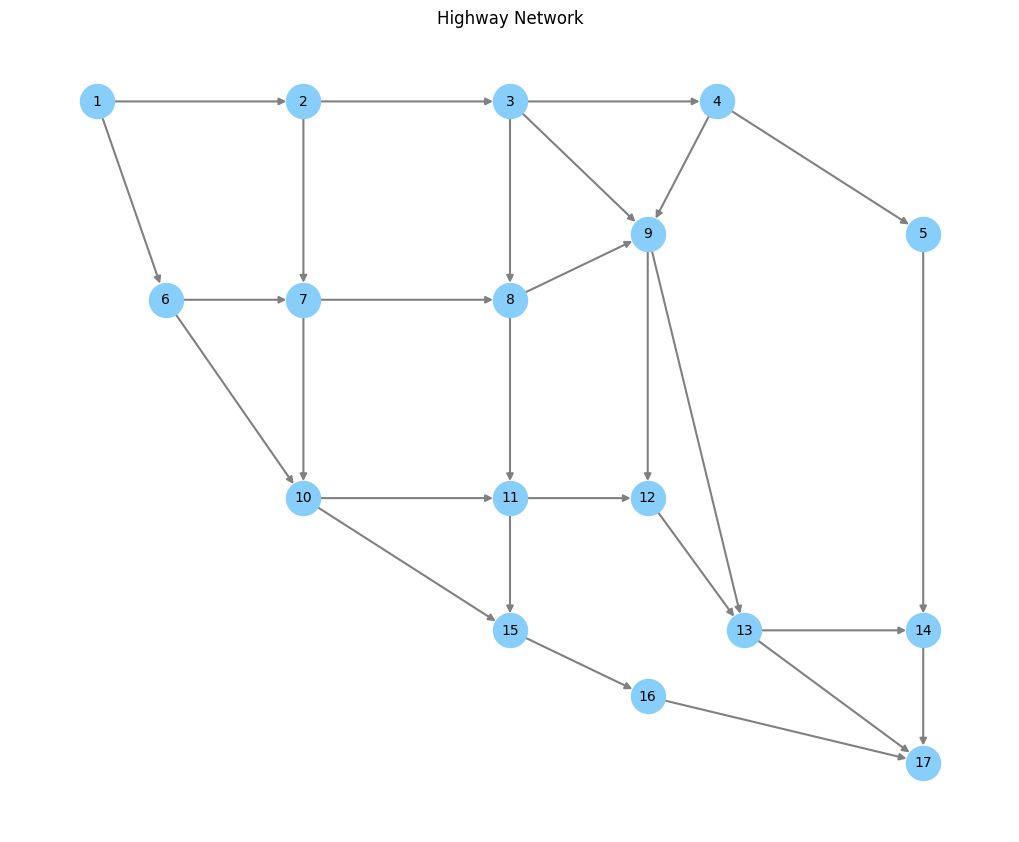

In [ ]:
# Create our directed graph
G = nx.DiGraph()

num_nodes, n_edges = B_matrix.shape

# a list to keep the start and end nodes of each edge: [(1, 2), (2, 3), ...]
links = []

# Iterate over B to read each column
for j in range(n_edges):
    start = None
    end = None
    for i in range(num_nodes):
        if B_matrix[i, j] == 1:
            start = i + 1  # Adjusting to 1-based index
        elif B_matrix[i, j] == -1:
            end = i + 1    # Adjusting to 1-based index

    links.append((start, end))
    # Ensure start and end are set before adding the edge
    if start is not None and end is not None:
        G.add_edge(start, end, travel_time=l_e_vec[j], capacity=c_e_vec[j])
    else:
        print(f"Warning: Link {j} could not find proper start or end.")


# Define positions for plotting the graph
pos = {1: (0, 0), 2: (1.5, 0), 3: (3, 0), 4: (4.5, 0), 5: (6, -1),
       6: (0.5, -1.5), 7: (1.5, -1.5), 8: (3, -1.5), 9: (4, -1), 10: (1.5, -3),
       11: (3, -3), 12: (4, -3), 13: (4.7, -4), 14: (6, -4), 15: (3, -4),
       16: (4, -4.5), 17: (6, -5)}

# Plot the graph
plt.figure(figsize=(10, 8))

# Draw the graph with enhanced visual properties
nx.draw(G, pos,
        with_labels=True,
        node_size=600,
        node_color="lightskyblue",
        font_size=10,
        edge_color="gray",
        width=1.5,
        arrows=True)

plt.title("Highway Network")
plt.show()



## Build Graph Object

In [ ]:
def build_graph_from_B(B, le, C):
    print("Building networkx graph...")
    if not issparse(B):
        B = csc_matrix(B)

    n_nodes, m_links = B.shape
    G = nx.DiGraph()
    G.add_nodes_from(range(1, n_nodes + 1))

    B_coo = B.tocoo()
    tails = {}
    heads = {}

    for i, j, v in zip(B_coo.row, B_coo.col, B_coo.data):
        node_idx = i
        link_idx = j
        node_num = node_idx + 1

        if v == 1:
            tails[link_idx] = node_num
        elif v == -1:
            heads[link_idx] = node_num

    for link_idx in range(m_links):
        if link_idx in tails and link_idx in heads:
            G.add_edge(tails[link_idx], heads[link_idx],
                       weight=float(le[link_idx]),
                       capacity=float(C[link_idx]),
                       link_index=link_idx)
    print("Graph built successfully.")
    return G

G = build_graph_from_B(B_matrix, l_e_vec, c_e_vec)

Building networkx graph...
Graph built successfully.


## E3 Part A: Shortest path (empty network)

Path nodes: [1, np.int32(2), np.int32(3), np.int32(9), np.int32(13), 17]
Path length (sum of l_e): 0.559833


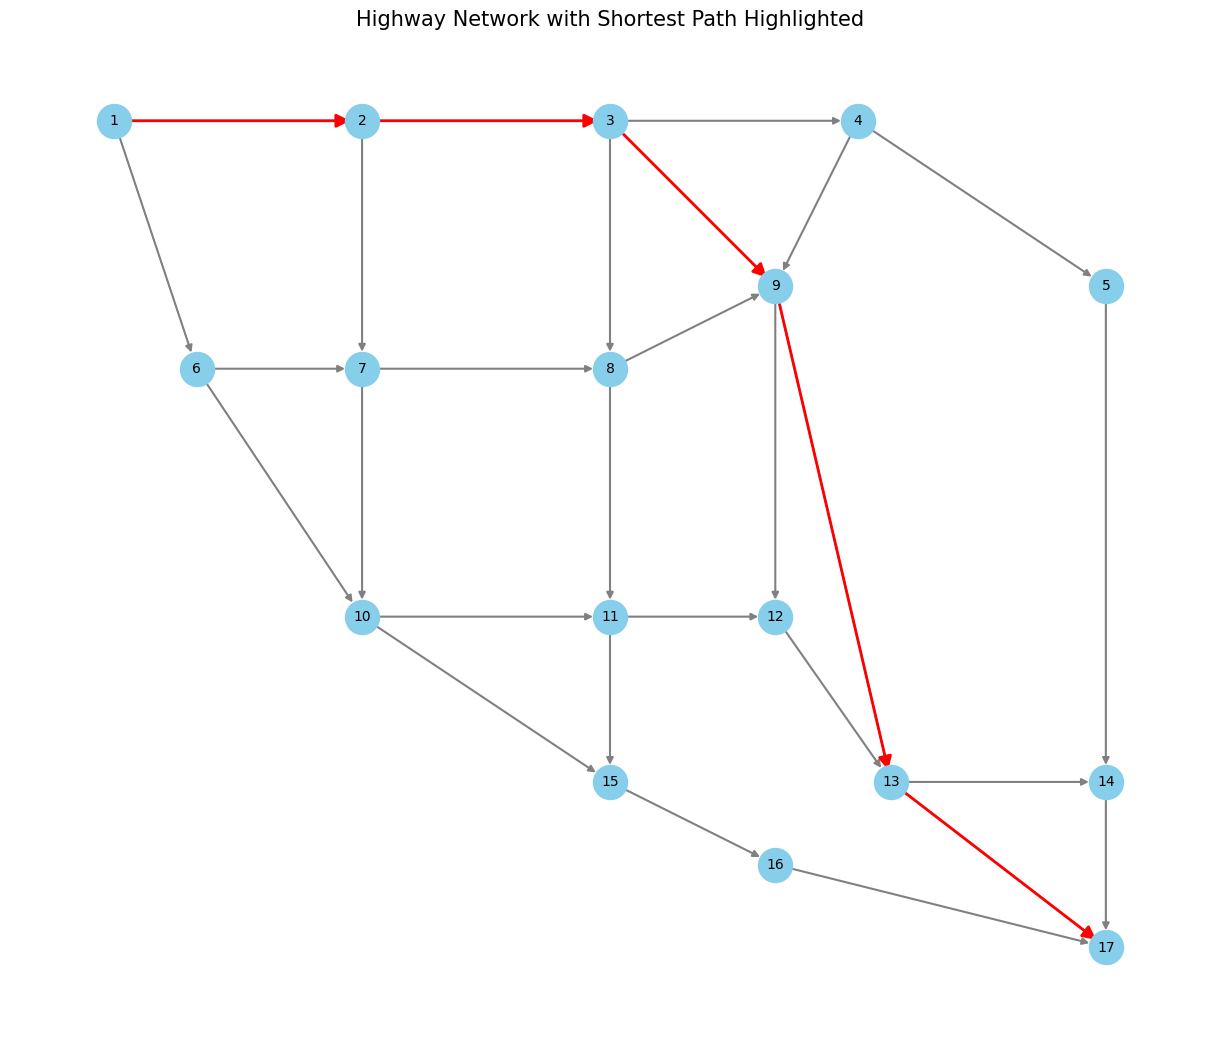

In [ ]:
try:
    sp_length = nx.shortest_path_length(G, source=SOURCE_NODE, target=SINK_NODE, weight='weight')
    sp_nodes = nx.shortest_path(G, source=SOURCE_NODE, target=SINK_NODE, weight='weight')
    print(f"Path nodes: {sp_nodes}")
    print(f"Path length (sum of l_e): {sp_length:.6f}")
except Exception as e:
    print(f"Error in shortest path: {e}")

shortest_path = nx.shortest_path(G, source=1, target=17, weight='travel_time')

# Prepare figure with enhanced visual properties
plt.figure(figsize=(12, 10))

# Draw the entire graph
nx.draw(G, pos, with_labels=True, node_size=600, node_color="skyblue", font_size=10, edge_color="gray", width=1.5, arrows=True)

# Highlight the shortest path with a thinner red arrow
shortest_path_edges = [(shortest_path[i], shortest_path[i + 1]) for i in range(len(shortest_path) - 1)]
nx.draw_networkx_edges(
    G, pos, edgelist=shortest_path_edges, edge_color='red', width=2, arrows=True, arrowstyle='-|>', arrowsize=20
)



# Set plot title and display the graph
plt.title("Highway Network with Shortest Path Highlighted", fontsize=15)
plt.show()

## E3 Part B: Maximum flow 1 -> 17

In [ ]:
try:
    flow_value, _ = nx.maximum_flow(G, SOURCE_NODE, SINK_NODE, capacity='capacity')
    print(f"Max flow value: {flow_value:.4f}")
except Exception as e:
    print(f"Error in max flow: {e}")

Max flow value: 22448.0000


## E3 Part C: Compute $\nu = B f$

In [ ]:
nu_vector = B_matrix @ f_given_vec
nu_1 = nu_vector[source_node_idx]
print(f"Source (node 1) net flow nu_1: {nu_1:.4f}\n")

# Print the net flow for all 17 nodes
print("Net flow vector (nu) for all 17 nodes:")
for i, nu_i in enumerate(nu_vector):
    node_number = i + 1  # (nodes are 1-indexed)
    print(f"  Node {node_number:<2}: {nu_i:>8.0f}")

# Set the demand D for the next parts
DEMAND_D_D = nu_1

Source (node 1) net flow nu_1: 16806.0000

Net flow vector (nu) for all 17 nodes:
  Node 1 :    16806
  Node 2 :     8570
  Node 3 :    19448
  Node 4 :     4957
  Node 5 :     -746
  Node 6 :     4768
  Node 7 :      413
  Node 8 :       -2
  Node 9 :    -5671
  Node 10:     1169
  Node 11:       -5
  Node 12:    -7131
  Node 13:     -380
  Node 14:    -7412
  Node 15:    -7810
  Node 16:    -3430
  Node 17:   -23544


## E3 Part D: Social optimum $f^*$

In [ ]:
print(f"Solving for balanced demand D = {DEMAND_D_D:.4f}")

f_e = cp.Variable(m_links, nonneg=True)

# Objective function (from PDF)
c_e_flat = np.array(c_e_vec).flatten()
l_e_flat = np.array(l_e_vec).flatten()

x = cp.multiply(f_e, 1.0 / c_e_flat)
one_minus_x = 1 - x
inv_term = cp.inv_pos(one_minus_x)
term_cost = cp.multiply(l_e_flat * c_e_flat, inv_term - 1)
objective = cp.Minimize(cp.sum(term_cost))

# Constraints (Balanced demand)
d_d = np.zeros(n_nodes)
d_d[source_node_idx] = DEMAND_D_D
d_d[sink_node_idx] = -DEMAND_D_D

constraints = [B_matrix @ f_e == d_d]

# Solve
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.ECOS)

if prob.status == 'optimal' or prob.status == 'optimal_inaccurate':
    print(f"Status: {prob.status}")

    f_star = f_e.value

    # Calculate total travel time sum(f * tau)
    travel_times = l_e_flat / (1 - f_star / c_e_flat)
    total_travel_time = np.sum(f_star * travel_times)

    print(f"Total Travel Time at System Optimum: {total_travel_time:.4f}")
    print("System Optimum Flow f* (first 10 links):")
    print(f_star[:10])
else:
    print(f"Status: {prob.status}. Could not find a solution.")

Solving for balanced demand D = 16806.0000
Status: optimal
Total Travel Time at System Optimum: 26142.6697
System Optimum Flow f* (first 10 links):
[ 6569.21899254  5809.94471754  3047.01642263  3047.01488268
 10236.78100746  4666.49462403  3061.22964159  2596.05762095
  3104.54611623   759.274275  ]


## E3 Part E: Wardrop equilibrium


In [ ]:
# Use the provided cost function to calculate the Wardrop equilibrium cost
def calculate_cost(flow):
    total_costs = np.array([0.0] * len(flow))
    for i, f in enumerate(flow):
        c = c_e_vec[i]
        l = l_e_vec[i]
        total_costs[i] = ((l * c) / (1 - (f / c))) - (l * c)
    return np.sum(total_costs)

# Wardrop equilibrium calculation
f_e = cp.Variable(m_links, nonneg=True)

# Flatten arrays
c_e_flat = np.array(c_e_vec).flatten()
l_e_flat = np.array(l_e_vec).flatten()
epsilon = 1e-6

# Define the cost function for Wardrop equilibrium
# ∫₀^f_e τ_e(s) ds = -l_e*c_e*ln(c_e-f_e) + l_e*c_e*ln(c_e)
cost_function_wardrop = cp.sum(-cp.multiply(l_e_flat * c_e_flat, cp.log(c_e_flat - f_e)) +
                                 cp.multiply(l_e_flat * c_e_flat, cp.log(c_e_flat)))

# Setting up the optimization problem for Wardrop equilibrium
objective_wardrop = cp.Minimize(cost_function_wardrop)

# Constraints (Balanced demand)
d_d = np.zeros(n_nodes)
d_d[source_node_idx] = DEMAND_D_D
d_d[sink_node_idx] = -DEMAND_D_D

constraints_wardrop = [B_matrix @ f_e == d_d, f_e >= 0, f_e <= c_e_flat - epsilon]
probW = cp.Problem(objective_wardrop, constraints_wardrop)

# Solve the optimization problem to get the Wardrop flow
probW.solve(solver=cp.ECOS)

if probW.status == 'optimal' or probW.status == 'optimal_inaccurate':
    wardrop_flow = f_e.value

    # Calculate the Wardrop cost using the flow values
    wardrop_cost = calculate_cost(wardrop_flow)

    # Output the results
    print(f"Status: {probW.status}")
    print(f'Wardrop Equilibrium Flow (first 10 links): {wardrop_flow}')
    print(f'Wardrop Equilibrium Cost (Calculated): {wardrop_cost:.4f}')

    # Calculate Price of Anarchy
    optimal_cost = calculate_cost(f_star)
    PoA = np.round(wardrop_cost / optimal_cost, 4)
    print(f"Price of Anarchy: {PoA}")



Status: optimal
Wardrop Equilibrium Flow (first 10 links): [6.55750885e+03 6.30858520e+03 2.20063122e+03 2.20063071e+03
 1.02484911e+04 4.70668177e+03 2.85993052e+03 2.23266476e+03
 3.35000396e+03 2.48923649e+02 1.16883954e+01 4.09626559e+03
 5.10378764e-04 2.20063071e+03 5.54180931e+03 2.34334916e+03
 5.29413504e+03 2.09567490e+03 6.38954155e+02 2.97892690e+03
 2.98230252e+03 5.96122942e+03 2.52244731e+03 8.02083961e-04
 6.78878606e+03 4.72307802e+03 5.29413585e+03 5.29413585e+03]
Wardrop Equilibrium Cost (Calculated): 26495.3210
Price of Anarchy: 1.0135


## E3 Part F: Wardrop equilibrium with tolls



In [ ]:
# Wardrop equilibrium with tolls calculation
f = cp.Variable(m_links)

# Define the tolls based on social optimum
omega = []
for i, value in enumerate(f_star):
    omega.append(value * ((c_e_vec[i] * l_e_vec[i]) / ((c_e_vec[i] - value) ** 2)))

# Define the cost function with tolls for Wardrop equilibrium
c_e_flat = np.array(c_e_vec).flatten()
l_e_flat = np.array(l_e_vec).flatten()

cost_function_with_tolls = cp.sum(cp.multiply(omega, f) - cp.multiply(c_e_flat * l_e_flat, cp.log(1 - cp.multiply(f, 1 / c_e_flat))))

# Set up the optimization problem for Wardrop equilibrium with tolls
objective_with_tolls = cp.Minimize(cost_function_with_tolls)
constraints_with_tolls = [B_matrix @ f == d_d, f >= 0, f <= c_e_flat]
prob_with_tolls = cp.Problem(objective_with_tolls, constraints_with_tolls)

# Solve the optimization problem to get the Wardrop flow with tolls
prob_with_tolls.solve(solver=cp.ECOS)

if prob_with_tolls.status == 'optimal' or prob_with_tolls.status == 'optimal_inaccurate':
    wardrop_flow_with_tolls = f.value

    # Calculate the Wardrop cost with tolls using the flow values
    wardrop_cost_with_tolls = calculate_cost(wardrop_flow_with_tolls)

    # Output the results
    print(f'Wardrop Equilibrium Flow with Tolls (first 10 links): {wardrop_flow_with_tolls}')
    print(f'Wardrop Equilibrium Cost with Tolls (Calculated): {wardrop_cost_with_tolls:.4f}')

    # Calculate the price of anarchy with tolls
    optimal_cost = calculate_cost(f_star)
    PoA_with_tolls = np.round(wardrop_cost_with_tolls / optimal_cost, 4)
    print(f"The price of Anarchy with tolls is: {PoA_with_tolls}")

Wardrop Equilibrium Flow with Tolls (first 10 links): [6.56901559e+03 5.81012345e+03 3.04688530e+03 3.04688525e+03
 1.02369844e+04 4.66657814e+03 3.06117722e+03 2.59573554e+03
 3.10454124e+03 7.58892142e+02 1.13324575e-04 2.76323804e+03
 4.58405808e-05 3.04688525e+03 5.57040623e+03 2.89379531e+03
 5.04090399e+03 2.36429306e+03 4.65441795e+02 2.25443238e+03
 3.35923704e+03 5.61366942e+03 2.37219531e+03 6.56036362e-05
 6.34601535e+03 5.41908056e+03 5.04090405e+03 5.04090405e+03]
Wardrop Equilibrium Cost with Tolls (Calculated): 26142.6691
The price of Anarchy with tolls is: 1.0


## E3 Part G: New cost function with tolls


In [ ]:
# define the flow variable
f = cp.Variable(m_links)

# define the cost function
cost_function = cp.sum(cp.multiply(l_e_flat * c_e_flat, cp.inv_pos(1 - cp.multiply(f, 1 / c_e_flat))) - l_e_flat * c_e_flat - cp.multiply(l_e_flat, f))

# define the optimization problem
objective = cp.Minimize(cost_function)

constraints = [B_matrix @ f == d_d, f >= 0, f <= c_e_flat - epsilon]  # 0 ≤ fe < ce.
problem = cp.Problem(objective, constraints)

# solve the optimization problem
problem.solve()

# extract the optimal flow
social_optimal_flow_tilde = f.value

social_optimal_cost_tilde = calculate_cost(social_optimal_flow_tilde)

# output the results
print(f'Social Optimal flow: {social_optimal_flow_tilde}') # Optimal value for
print(f'Optimal Cost: {np.round(social_optimal_cost_tilde, 2)}')

Social Optimal flow: [6.58451091e+03 5.57770824e+03 3.36756475e+03 3.36755932e+03
 1.02214891e+04 4.66944310e+03 3.15651862e+03 2.71195152e+03
 2.98789183e+03 1.00680267e+03 3.72675333e-03 2.21013977e+03
 5.42663108e-03 3.36755932e+03 5.55204599e+03 3.08485436e+03
 4.98691878e+03 2.51972715e+03 4.44570825e+02 1.93420488e+03
 3.52942308e+03 5.46362796e+03 2.20221142e+03 2.10793837e-03
 6.24930837e+03 5.56977074e+03 4.98692089e+03 4.98692089e+03]
Optimal Cost: 26187.2


In [ ]:
# define the tolls based on the social optimum
omega = []
for i, value in enumerate(social_optimal_flow_tilde):
    omega.append(value * ((c_e_flat[i] * l_e_flat[i]) / ((c_e_flat[i] - value) ** 2)) - l_e_flat[i])

f = cp.Variable(m_links, nonneg=True)

# define the cost function with tolls
cost_function_with_tolls = cp.sum(-cp.multiply(l_e_flat * c_e_flat, cp.log(c_e_flat - f)) + cp.multiply(l_e_flat * c_e_flat, cp.log(c_e_flat)) + cp.multiply(omega, f))

# set up the optimization problem with tolls
objective_with_tolls = cp.Minimize(cost_function_with_tolls)
constraints = [B_matrix @ f == d_d, f >= 0, f <= c_e_flat - epsilon] # 0 ≤ fe < ce.


prob_with_tolls = cp.Problem(objective_with_tolls, constraints)

# solve the optimization problem
result_with_tolls = prob_with_tolls.solve()
wardrop_flow_with_tolls_tilde = f.value

# calculate the cost based on the flow values
wardrop_cost_with_tolls_tilde = calculate_cost(wardrop_flow_with_tolls_tilde)

# output the results
print(f'Wardrop Equilibrium Flow with Tolls: {wardrop_flow_with_tolls_tilde}')
print(f'Wardrop Equilibrium Cost with Tolls (Calculated): {np.round(wardrop_cost_with_tolls_tilde, 2)}')
# calculate the price of anarchy with tolls
PoA_with_tolls_tilde = np.round(wardrop_cost_with_tolls_tilde / social_optimal_cost_tilde, 4)
print(f"The price of Anarchy with tolls is: {PoA_with_tolls_tilde}")

Wardrop Equilibrium Flow with Tolls: [6.58393730e+03 5.57850452e+03 3.36692127e+03 3.36691933e+03
 1.02220626e+04 4.66971795e+03 3.15592951e+03 2.71248739e+03
 2.98776194e+03 1.00543278e+03 1.14620854e-03 2.21158211e+03
 1.93667773e-03 3.36691933e+03 5.55234470e+03 3.08456831e+03
 4.98699761e+03 2.51922121e+03 4.43443270e+02 1.93630949e+03
 3.52801108e+03 5.46432057e+03 2.20277425e+03 5.02526133e-04
 6.24930826e+03 5.56969359e+03 4.98699811e+03 4.98699811e+03]
Wardrop Equilibrium Cost with Tolls (Calculated): 26186.96
The price of Anarchy with tolls is: 1.0
